# Krediitkaardi pettuste tuvastamine

> **Märkus:** Jooksuta lahtreid **järjestikku ülevalt alla** (Shift+Enter). Kui jooksutad lahtreid valest järjekorrast, võivad tekkida vead nagu . Alusta alati ülevalt.

In [1]:
# ── Teekide paigaldamine (jooksuta üks kord) ──────────────────────────────
%pip install imbalanced-learn lightgbm fpdf2 -q

# ── Põhilised impordid ────────────────────────────────────────────────────
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Kõik teegid laaditud.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Kõik teegid laaditud.


## Probleemi püstitus

### Mida püüame ennustada?

Selles projektis uurime, kas on võimalik tuvastada **pettuslikke krediitkaardi tehinguid** automaatselt.

Mudel vaatab iga tehingut ja vastab küsimusele: **kas see tehing on pettus või normaalne?**

- **Sisend:** tehingu andmed (aeg, summa ja 28 anonüümitud tunnust)
- **Väljund:** 0 = normaalne tehing, 1 = pettus

Andmestik: [Credit Card Fraud Detection – Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### Miks see probleem on oluline?

Krediitkaardipettused põhjustavad pangandussektoris igal aastal miljardeid eurosid kahju. Automaatne tuvastamine on vajalik, et:
- kaitsta kliente — nad ei peaks maksma ostude eest, mida nad ei teinud
- reageerida kiiresti — inimene ei jõua käsitsi kõiki tehinguid kontrollida
- vähendada kahju pankadele ja kaupmeestele

Andmestik on **tugevalt tasakaalustamata** — ainult 0,172% tehingutest on pettused. See tähendab, et lihtsad lahendused ei tööta hästi ja probleem on tehniliselt huvitav.

### Võimalikud uurimissuunad

- Kui hästi suudab mudel pettusi tuvastada?
- Millised tunnused on kõige informatiivsemad pettuse tuvastamisel?
- Kuidas mõjutab tasakaalustamata andmestik mudeli tulemust ja milliseid meetodeid (nt SMOTE) võiks selle leevendamiseks kasutada?

## Andmestiku kirjeldus

## Andmete allikas

**Allikas:** [Credit Card Fraud Detection – Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### Kontekst
Krediitkaardi ettevõtetel on oluline tuvastada pettuslikud tehingud, et kliendid ei peaks maksma kaupade eest, mida nad ei ostnud.

### Sisu
Andmestik sisaldab Euroopa krediitkaardi omanike tehinguid septembrist 2013. Andmestik hõlmab kahe päeva tehinguid, milles on **492 pettust 284 807 tehingust**. Andmestik on tugevalt tasakaalustamata — positiivne klass (pettused) moodustab vaid **0,172%** kõigist tehingutest.

Andmestik sisaldab ainult arvulisi tunnuseid, mis on **PCA** transformatsiooni tulemus.

> **Mis on PCA?** PCA (Principal Component Analysis) on matemaatiline meetod andmete anonümiseerimiseks ja kokku pakkimiseks. Pank ei saanud avaldada päris tehinguandmeid (kaardi number, kauplus, asukoht) — see oleks konfidentsiaalne. PCA abil teisendati originaalandmed anonüümseteks tunnusteks V1–V28. Algandmeid ei saa tagasi arvutada, aga mustrid (sh pettuse mustrid) säilivad.

Konfidentsiaalsuse tõttu ei ole algandmed avalikustatud. Tunnused V1–V28 on PCA peakomponendid. Tunnused **Time** ja **Amount** ei ole PCA-ga teisendatud.

Klasside tasakaalustamatuse tõttu on soovitatav täpsuse mõõtmiseks kasutada **AUPRC-d** (Area Under the Precision-Recall Curve), mitte tavalise klassifitseerimistäpsuse meetrikat.

### Andmete laadimine

In [2]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Tunnuste (feature'ite) kirjeldus

| Tunnus | Kirjeldus |
|--------|-----------|
| **Time** | Mitu sekundit on möödunud andmestiku esimesest tehingust |
| **V1–V28** | Anonüümitud tunnused — algandmed on konfidentsiaalsuse tõttu peidetud matemaatilise teisenduse taha. Me ei tea, mida need täpselt mõõdavad. |
| **Amount** | Tehingu summa eurodes |
| **Class** | 1 = pettus, 0 = normaalne tehing |

## Andmestiku suurus ja struktuur

In [3]:
print("Ridade ja veergude arv:", df.shape)
print("\nVeergude nimed:")
print(df.columns.tolist())
print("\nPuuduvad väärtused:")
print(df.isnull().sum().sum(), "puuduvat väärtust")
print("\nAndmestiku info:")
df.info()

Ridade ja veergude arv: (284807, 31)

Veergude nimed:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Puuduvad väärtused:
0 puuduvat väärtust

Andmestiku info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 1

## Andmete analüüs (EDA)

## Põhistatistika (keskmine, jaotus jne)

Statistiline kokkuvõte:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Klasside jaotus:
Class
0    284315
1       492
Name: count, dtype: int64

Pettuste osakaal: 0.1727%


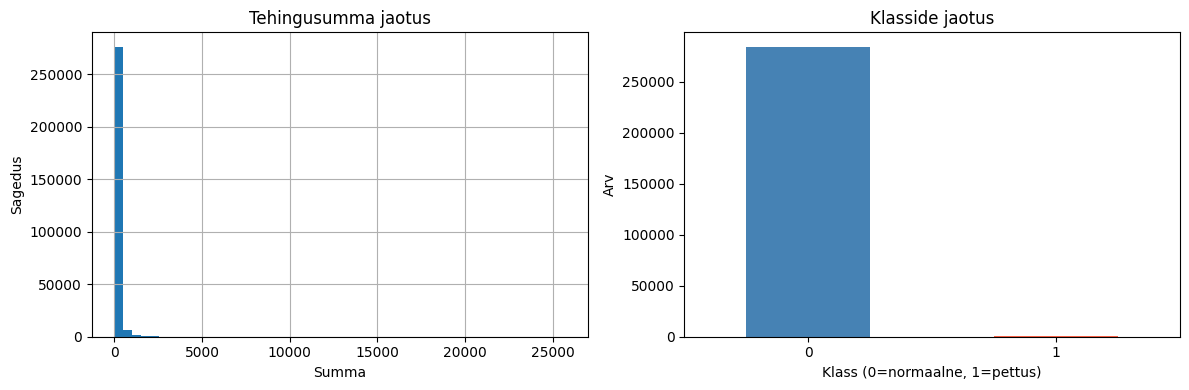

In [4]:
import matplotlib.pyplot as plt

# Statistiline kokkuvõte
print("Statistiline kokkuvõte:")
display(df.describe())

# Klasside jaotus (pettus vs. normaalne)
print("\nKlasside jaotus:")
print(df['Class'].value_counts())
print(f"\nPettuste osakaal: {df['Class'].mean()*100:.4f}%")

# Tehingusumma jaotus
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Amount'].hist(bins=50, ax=axes[0])
axes[0].set_title('Tehingusumma jaotus')
axes[0].set_xlabel('Summa')
axes[0].set_ylabel('Sagedus')

df['Class'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Klasside jaotus')
axes[1].set_xlabel('Klass (0=normaalne, 1=pettus)')
axes[1].set_ylabel('Arv')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Mida graafikud näitavad?**

- **Tehingusumma jaotus (vasak):** Enamik tehinguid on väikese summaga (0–500€). Üle 5000€ tehinguid on väga vähe — igapäevased ostud on tavaliselt odavad.

- **Klasside jaotus (parem):** Normaalseid tehinguid on ~280 000, pettusi ainult 492. Punane tulp on nii väike, et seda peaaegu ei näe. See on meie suurim väljakutse — mudel peab leidma "nõela heinakuhjas".

## Visualiseeringud (graafikud)

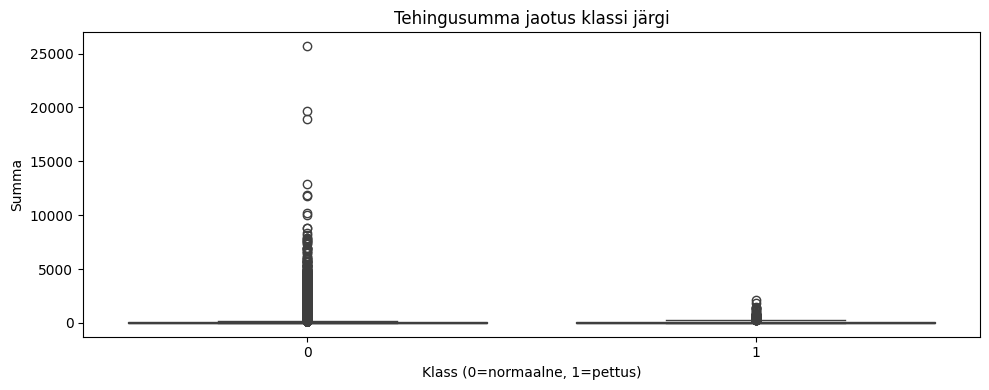

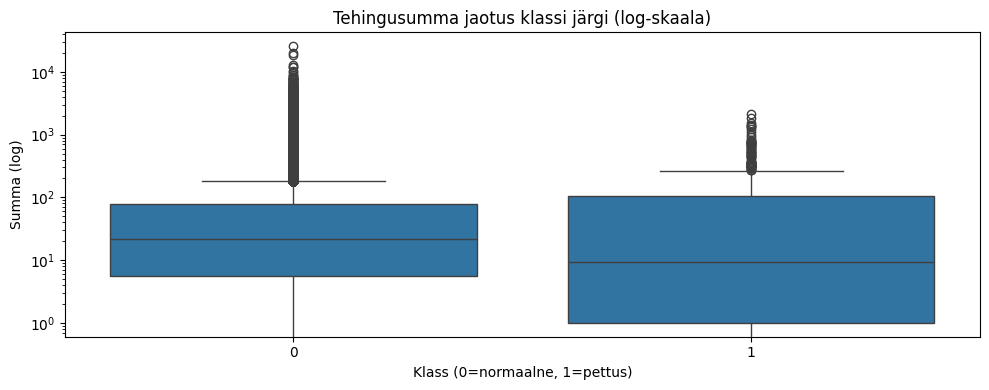

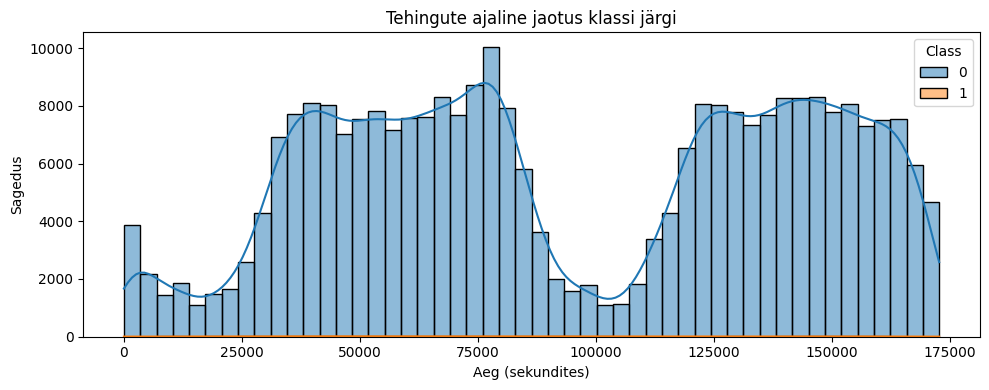

In [5]:
import seaborn as sns

# Tehingusumma jaotus klassi järgi
plt.figure(figsize=(10, 4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Tehingusumma jaotus klassi järgi')
plt.xlabel('Klass (0=normaalne, 1=pettus)')
plt.ylabel('Summa')
plt.tight_layout()
plt.show()

# Tehingusumma log-skaalal klassi järgi
plt.figure(figsize=(10, 4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.title('Tehingusumma jaotus klassi järgi (log-skaala)')
plt.xlabel('Klass (0=normaalne, 1=pettus)')
plt.ylabel('Summa (log)')
plt.tight_layout()
plt.show()

# Ajaline jaotus klassi järgi
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=True)
plt.title('Tehingute ajaline jaotus klassi järgi')
plt.xlabel('Aeg (sekundites)')
plt.ylabel('Sagedus')
plt.tight_layout()
plt.show()

**Mida see graafik näitab?**

- **Normaalsed tehingud (vasak, klass 0):** Enamik on väikese summaga, kuid esineb ka suuri tehinguid kuni 25 000€ — inimesed teevad nii väikesi kui suuri oste.
- **Pettused (parem, klass 1):** Pettused on peaaegu kõik väikese summaga, maksimaalselt ~2500€. Üle 5000€ pettusi praktiliselt pole.

**Miks?** Pettuse tegijad eelistavad väikseid summasid — suured tehingud tõmbavad rohkem tähelepanu ja aktiveerivad kiiremini kaardi blokeerimise. See on mudelile kasulik signaal.

**Log-skaala graafiku lugemine:**

**Log-skaala** tähendab, et y-telg ei kasva ühtlaselt (1, 2, 3...) vaid kümnekordselt (1 → 10 → 100 → 1000...). See aitab näha väikeste väärtuste erinevusi paremini, kui andmed on väga eri skaaladel.

- **Normaalsed tehingud (0):** mediaan ~20€, enamik tehinguid vahemikus 5–80€
- **Pettused (1):** mediaan ~10€, enamik tehinguid vahemikus 1–100€

**Tähtis järeldus:** Pettuste summad on küll veidi väiksemad, aga erinevus pole tegelikult nii suur. See tähendab, et **summa üksi ei ole piisav pettuse tuvastamiseks** — mudel peab toetuma rohkem V1–V28 tunnustele.

**Tehingute ajalise jaotuse lugemine:**

X-telg on aeg sekundites — andmestik katab 2 päeva (~172 800 sekundit).

- **Normaalsed tehingud (sinine):** Kaks selget tippu — üks ~75 000 ja teine ~140 000 sekundi juures. See vastab kahele päevale — hommikust õhtuni on tehinguid palju, öösel vähe (langus keskel ~100 000 juures).
- **Pettused (oranž):** Nii õhuke joon, et peaaegu ei näe — absoluutarvudes tundub ühtlane.

**NB:** See graafik näitab absoluutarve — kuna pettusi on väga vähe, ei ole trend nähtav. Osakaaluna vaadates (vt järgmine graafik) selgub, et teatud kellaaegadel on pettusi kuni 6–7 korda rohkem kui teistel.

### Pettuste osakaal ajas

Eelmine graafik näitas absoluutarve — pettuste joon oli nii madal, et trendi polnud näha. Vaatame hoopis **osakaalu**: mitu protsenti tehingutest igas ajavahemikus on pettused?

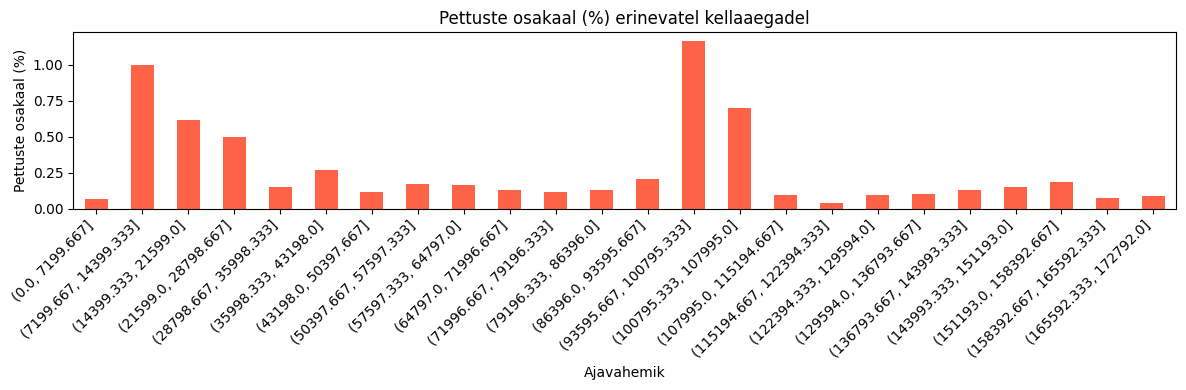

Kõrgeim pettuste osakaal: 1.17% (vahemik: (93595.667, 100795.333])
Madalaim pettuste osakaal: 0.04% (vahemik: (115194.667, 122394.333])


In [6]:
import numpy as np

# Kasuta ajutist koopiat et df ei muutuks
df_time = df.copy()
bins = np.linspace(df_time['Time'].min(), df_time['Time'].max(), 25)
df_time['time_bin'] = pd.cut(df_time['Time'], bins=bins)

osakaal = df_time.groupby('time_bin')['Class'].mean() * 100

plt.figure(figsize=(12, 4))
osakaal.plot(kind='bar', color='tomato')
plt.title('Pettuste osakaal (%) erinevatel kellaaegadel')
plt.xlabel('Ajavahemik')
plt.ylabel('Pettuste osakaal (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Kõrgeim pettuste osakaal: {osakaal.max():.2f}% (vahemik: {osakaal.idxmax()})")
print(f"Madalaim pettuste osakaal: {osakaal.min():.2f}% (vahemik: {osakaal.idxmin()})")

**Pettuste osakaal ajas — kuidas lugeda:**

Iga tulp näitab: mitu protsenti selles ajavahemikus tehtud tehingutest olid pettused.

- **Kõrgeim osakaal ~1.17%** — umbes esimese päeva lõpus/öösel (~93 000–100 000 sekundit)
- **Madalaim osakaal ~0.04%** — teatud päevasel ajal (~115 000–122 000 sekundit)

**Tähtis järeldus:** Erinevus on **~6–7 korda** — teatud kellaaegadel on pettusi suhteliselt palju rohkem. See tähendab, et **aeg on siiski kasulik signaal** mudelile, isegi kui absoluutarvudes seda ei paistnud.

## Seoste leidmine tunnuste vahel

Top 10 tunnust, mis on klassiga kõige rohkem korreleeritud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


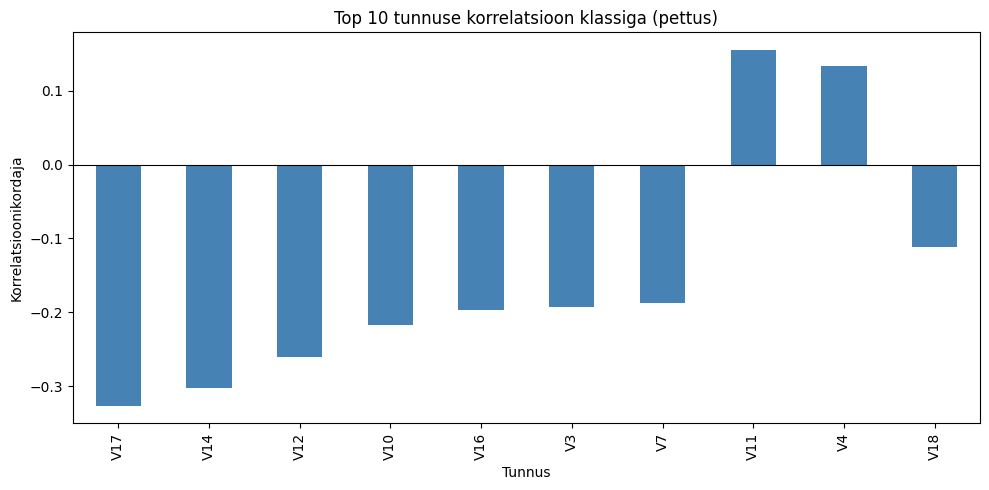

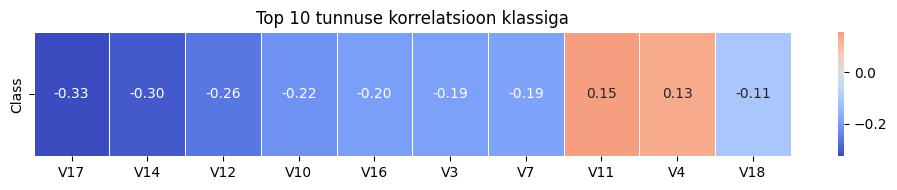

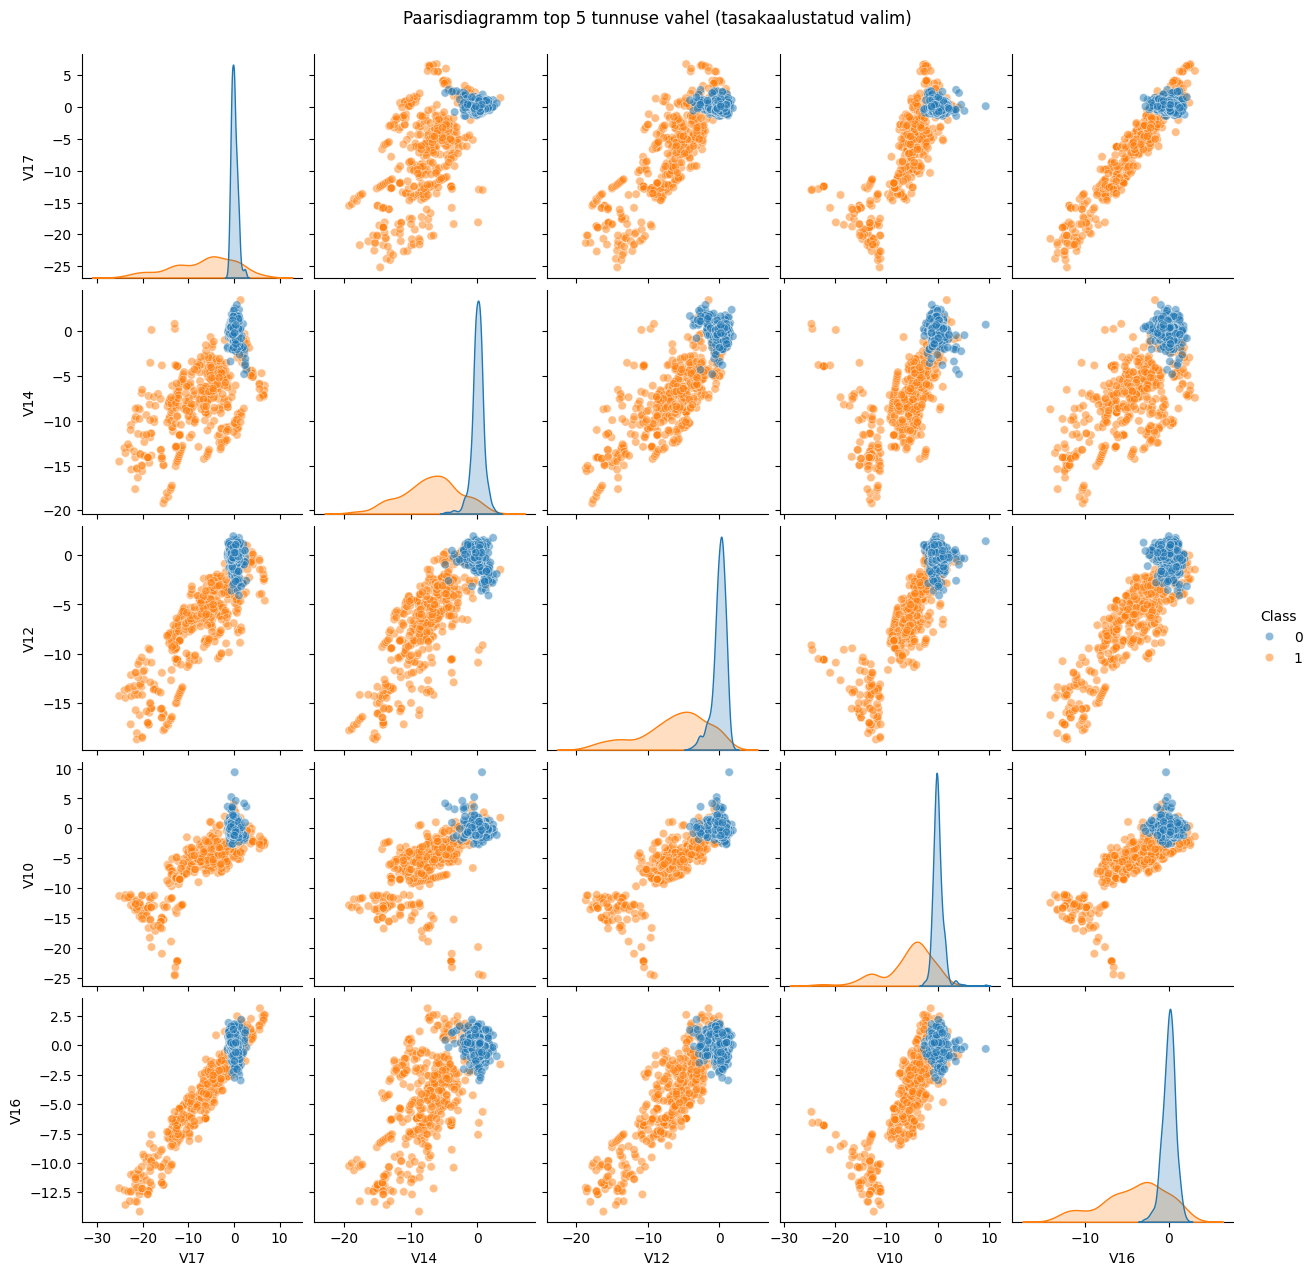

In [7]:
# Korrelatsioon klassiga - tulpdiagramm
corr_with_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("Top 10 tunnust, mis on klassiga kõige rohkem korreleeritud:")
print(corr_with_class.head(10))

plt.figure(figsize=(10, 5))
corr_with_class.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 tunnuse korrelatsioon klassiga (pettus)')
plt.xlabel('Tunnus')
plt.ylabel('Korrelatsioonikordaja')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Korrelatsioon klassiga - heatmap (ainult klassiga seotud tunnused)
plt.figure(figsize=(10, 2))
sns.heatmap(corr_with_class.head(10).to_frame().T, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
plt.title('Top 10 tunnuse korrelatsioon klassiga')
plt.tight_layout()
plt.show()

# Paarisdiagramm - tasakaalustatud valim (võrdne arv pettusi ja normaalseid)
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
balanced_df = pd.concat([fraud, normal])

top_features = corr_with_class.head(5).index.tolist() + ['Class']
sns.pairplot(balanced_df[top_features], hue='Class', plot_kws={'alpha': 0.5})
plt.suptitle('Paarisdiagramm top 5 tunnuse vahel (tasakaalustatud valim)', y=1.02)
plt.show()

**Graafiku lugemine:**

- **Negatiivne korrelatsioon (tulbad allpool 0):** V17, V14, V12 jt — kui nende väärtus on madal, on suurem tõenäosus, et tehing on pettus.
- **Positiivne korrelatsioon (tulbad ülespool 0):** V11, V4 — kui nende väärtus on kõrge, on suurem tõenäosus, et tehing on pettus.
- **Tugevaim signaal on V17 ja V14** — pikimad tulbad, ehk need tunnused eristavad pettusi kõige paremini.

Kuna V-tunnused on anonüümitud, ei tea me mida need täpselt mõõdavad — aga mudel oskab neid numbreid pettuse tuvastamiseks kasutada.

**Heatmap — sama info, teises vormis:**

- **Sinine** = negatiivne korrelatsioon (mida tumedam, seda tugevam seos pettusega)
- **Oranž** = positiivne korrelatsioon
- **Arv lahtris** = täpne väärtus (nt V17 = -0.33, V11 = 0.15)

Eelise eelmine tulpdiagrammi ees: numbrid on otse peal — saad täpsed väärtused ilma graafikut mõõtmata.

**Paarisdiagrammi lugemine:**

- **Diagonaal:** Jaotusgraafikud — näitavad kuidas ühe tunnuse väärtused jaotuvad. Sinine = normaalne tehing, oranž = pettus. Näed, et kaks klassi asuvad erinevates kohtades.
- **Ülejäänud lahtrid:** Iga lahter näitab kahe tunnuse seost punktpilvena — nt rida V17 ja veerg V14 näitab nende kahe tunnuse omavahelist seost.

**Mida tähele panna:** Sinised ja oranžid punktid on **selgelt eraldatud** — pettused ja normaalsed tehingud asuvad eri piirkondades. Mida selgemalt need eralduvad, seda paremini suudab mudel pettusi ära tunda. Siin on eraldus hea — eriti V17 ja V14 puhul.

## Kokkuvõte: mida andmed näitavad?

### Andmestiku üldpilt
- Andmestik on **tugevalt tasakaalustamata** — pettused moodustavad vaid **0,172%** tehingutest (492 pettust 284 807-st)
- Puuduvaid väärtusi ei ole — andmestik on puhas ja töötlemiseks valmis

### Olulised seosed

**Tehingusumma (Amount):**
- Pettuslikud tehingud on **keskmiselt väiksema summaga** kui normaalsed tehingud
- Erinevus pole aga nii suur kui esmapilgul tundub — summa üksi ei ole piisav pettuse tuvastamiseks

**Aeg (Time):**
- Normaalsed tehingud järgivad **päevarütmi** — kaks selget tippu (kaks päeva), öösel tehinguid vähe
- Absoluutarvudes tundub pettuste joon ühtlane — aga osakaaluna vaadates on teatud kellaaegadel pettusi kuni **6–7 korda rohkem**. Aeg on seega siiski kasulik signaal mudelile.

**PCA tunnused (V1–V28):**
- Kõige tugevamad korrelatsioonid klassiga on näha allolevas koodis
- Need tunnused on **kõige informatiivsemad** pettuse tuvastamisel

### Järeldus
Andmestiku suurim väljakutse on **klasside tasakaalustamatus**. Selle lahendamiseks kasutame kahte lähenemist:

> **SMOTE** — kuna pettusi on väga vähe, loob SMOTE kunstlikult uusi sarnaseid pettuse näiteid, et mudel saaks treenimise ajal piisavalt näiteid mõlemast klassist.

> **AUPRC** — tavalist täpsust (accuracy) ei saa kasutada, sest mudel saaks 99,8% "õigesti" lihtsalt öeldes kõige kohta "normaalne". AUPRC mõõdab hoopis kui hästi mudel tasakaalustab pettuste tabamist (Recall) ja valede häirete vältimist (Precision). Väärtus on 0–1, kõrgem on parem.

In [8]:
top4 = corr_with_class.head(4).index.tolist()
neg = corr_with_class[corr_with_class < 0].head(3).index.tolist()
pos = corr_with_class[corr_with_class > 0].head(2).index.tolist()

print(f"Top 4 klassiga korreleeritud tunnust: {', '.join(top4)}")
print(f"  Negatiivne korrelatsioon: {', '.join(neg)}")
print(f"  Positiivne korrelatsioon: {', '.join(pos)}")

Top 4 klassiga korreleeritud tunnust: V17, V14, V12, V10
  Negatiivne korrelatsioon: V17, V14, V12
  Positiivne korrelatsioon: V11, V4


## Andmete eeltöötlus

### Puuduvate väärtuste käsitlemine

Enne mudeli treenimist on oluline kontrollida, kas andmestikus esineb puuduvaid väärtusi. Puuduvad väärtused võivad mudelite töö häirida ja viia ebatäpsete tulemusteni.

In [9]:
print("Puuduvate väärtuste kontroll tehti juba andmestiku struktuuri osas.")
print("Tulemus: andmestikus puuduvaid väärtusi ei ole — edasine käsitlemine pole vajalik.")

Puuduvate väärtuste kontroll tehti juba andmestiku struktuuri osas.
Tulemus: andmestikus puuduvaid väärtusi ei ole — edasine käsitlemine pole vajalik.


### Kategooriliste tunnuste kodeerimine

Masinõppe mudelid saavad töötada ainult **arvudega** — teksti või kategooriaid (nt "jah/ei", "punane/sinine") nad otse ei mõista. Sellisel juhul tuleks need teisendada arvudeks.

Kontrollime, kas meie andmestikus on selliseid tunnuseid.

In [10]:
kategoorilised = df.select_dtypes(include=['object', 'category']).columns.tolist()

if kategoorilised:
    print("Kategoorilised tunnused:", kategoorilised)
    # Kodeerimine vajadusel
    df = pd.get_dummies(df, columns=kategoorilised)
    print("Kodeerimine tehtud.")
else:
    print("Kategoorilisi tunnuseid ei leitud — kõik tunnused on arvulised, kodeerimine pole vajalik.")

Kategoorilisi tunnuseid ei leitud — kõik tunnused on arvulised, kodeerimine pole vajalik.


## Mudeli loomine

Proovime kolme erinevat masinõppe mudelit ja võrdleme nende tulemusi:

| Mudel | Põhimõte | Lühikirjeldus |
|-------|----------|---------------|
| **Logistic Regression** | Vaatab iga tunnuse väärtust ja arvutab neile kaalud. Liidab kokku ja annab lõpptõenäosuse. | Lihtne ja kiire baasmudel — hea lähtepunkt võrdluseks |
| **Random Forest** | Ehitab palju erinevaid "otsusepuid", igaüks küsib erinevaid küsimusi. Lõpptulemus on kõigi puude hääletus. | Täpsem, kombineerib palju erinevaid vaatepunkte |
| **LightGBM** | Sarnane Random Forestiga, aga iga uus puu parandab eelmise vigu. | Kiire ja täpne, eriti suurtel andmestikel |

Kõik mudelid treenitakse SMOTE-ga tasakaalustatud andmetel.

### Andmete jagamine ja skaleerimine

Enne mudeli treenimist jagame andmed kolmeks:
- **Treeningandmed (70%)** — mudel õpib nende peal
- **Valideerimisandmed (15%)** — läve optimeerimine ja häälestamine
- **Testandmed (15%)** — lõplik hindamine andmetel, mida mudel pole näinud

Pärast jagamist **skaleerime** tunnused  ja  — viime need samale skaalale teiste tunnustega. Tehakse **ainult treeningandmetel**, seejärel  kõigil kolmel. Kui skaleerida enne splitti, lekiks val/test andmete info treeningusse — mudel näeks tulevasi andmeid ette.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Class', axis=1)
y = df['Class']

# Jagame andmed kolmeks: 70% treening, 15% valideerimine, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Skaleerimine — fit ainult treeningandmetel, transform kõigil
scaler = StandardScaler()
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val[['Time', 'Amount']]   = scaler.transform(X_val[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

print(f"Treeningandmed:       {X_train.shape[0]} rida ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Valideerimisandmed:   {X_val.shape[0]} rida ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Testandmed:           {X_test.shape[0]} rida ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nPettuste osakaal treeningus:       {y_train.mean()*100:.3f}%")
print(f"Pettuste osakaal valideerimises:   {y_val.mean()*100:.3f}%")
print(f"Pettuste osakaal testis:           {y_test.mean()*100:.3f}%")


Treeningandmed:       199364 rida (70%)
Valideerimisandmed:   42721 rida (15%)
Testandmed:           42722 rida (15%)

Pettuste osakaal treeningus:       0.173%
Pettuste osakaal valideerimises:   0.173%
Pettuste osakaal testis:           0.173%


### Klasside tasakaalustamatus

Meie andmestikus on ainult 0,172% pettusi. See tähendab, et kui mudel ütleks **iga** tehingu kohta "normaalne", oleks ta 99,8% ajast "õige" — aga pettusi ei tuvastaks ta üldse.

Kujuta ette, et õpetad last eristama kasse ja koeri, aga näitad talle 1000 koera pilti ja ainult 2 kassi pilti. Ta õpib kiiresti ütlema kõige kohta "koer".

**SMOTE** lahendab selle: ta loob kunstlikult uusi pettuse näiteid, et mudel näeks mõlemat klassi piisavalt palju. Seda tehakse ainult treeningandmetele — testandmed jäävad puutumata, et tulemus oleks aus.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Enne SMOTE — normaalne: {(y_train==0).sum()}, pettus: {(y_train==1).sum()}")
print(f"Pärast SMOTE — normaalne: {(y_train_sm==0).sum()}, pettus: {(y_train_sm==1).sum()}")

Enne SMOTE — normaalne: 199020, pettus: 344
Pärast SMOTE — normaalne: 199020, pettus: 199020


### Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Normaalne', 'Pettus']))
print(f"AUPRC: {average_precision_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

   Normaalne       1.00      0.98      0.99     42648
      Pettus       0.06      0.88      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.55     42722
weighted avg       1.00      0.98      0.99     42722

AUPRC: 0.7943


**Logistic Regression tulemuste lugemine:**

- **Normaalne tehing:** Precision 1.00 ja Recall 0.98 — mudel tuvastab normaalsed tehingud väga hästi
- **Pettus — Recall 0.88** ✓ — 88% tegelikest pettustest tabatakse
- **Pettus — Precision 0.06** ⚠️ — kui mudel ütleb „pettus“, on see tegelikult pettus ainult 6% korda. 94% on valed häired — kliente blokeeritakse asjatult väga tihti.

**AUPRC 0.7943** — keskmise tasemel tulemus. See on baasmudel — Random Forest ja LightGBM peaksid andma parema tulemuse.


### LightGBM

In [14]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score

lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train_sm, y_train_sm)
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm, target_names=['Normaalne', 'Pettus']))
print(f"AUPRC: {average_precision_score(y_test, y_prob_lgbm):.4f}")

=== LightGBM ===
              precision    recall  f1-score   support

   Normaalne       1.00      1.00      1.00     42648
      Pettus       0.58      0.82      0.68        74

    accuracy                           1.00     42722
   macro avg       0.79      0.91      0.84     42722
weighted avg       1.00      1.00      1.00     42722

AUPRC: 0.7969


**LightGBM tulemuste lugemine — palju parem kui Logistic Regression!**

- **Normaalne tehing:** Kõik näitajad 1.00 — normaalsed tehingud tuvastatakse peaaegu täiuslikult
- **Pettus — Recall 0.82** — 82% tegelikest pettustest tabatakse
- **Pettus — Precision 0.58** ✓ — kui mudel ütleb „pettus“, on see õige rohkem kui pooltel kordadel. Tohutu paranemine võrreldes Logistic Regression-i 6%-ga.

**AUPRC 0.7969** — märkimisväärselt parem kui Logistic Regression (0.7943). LightGBM tekitab palju vähem valesid häireid — klienti blokeeritakse ainult siis kui mudel on üsna kindel.


### Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normaalne', 'Pettus']))
print(f"AUPRC: {average_precision_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

   Normaalne       1.00      1.00      1.00     42648
      Pettus       0.87      0.81      0.84        74

    accuracy                           1.00     42722
   macro avg       0.93      0.91      0.92     42722
weighted avg       1.00      1.00      1.00     42722

AUPRC: 0.8275


**Random Forest tulemuste lugemine — kolmest mudelist parim!**

- **Normaalne tehing:** Kõik näitajad 1.00 — normaalsed tehingud täiuslikult tuvastatud
- **Pettus — Recall 0.81** — 81% tegelikest pettustest tabatakse
- **Pettus — Precision 0.87** ✓✓ — kui mudel ütleb „pettus“, on see õige 87% korda — suurepärane tulemus!

**AUPRC 0.8275** — kõrgeim kõigist kolmest mudelist.

| Mudel | Precision | Recall | AUPRC |
|-------|-----------|--------|-------|
| Logistic Regression | 0.06 | 0.88 | 0.7943 |
| LightGBM | 0.58 | 0.82 | 0.7969 |
| **Random Forest** | **0.87** | **0.81** | **0.8275** |

Random Forest on kõige tasakaalustatum — hea Precision ja Recall samaaegselt. Kliente blokeeritakse harva asjatult ja enamik pettusi tabatakse.


### SMOTE mõju võrdlus

Võrdleme Random Forest mudelit **ilma SMOTE-ta** ja **SMOTE-ga**, et näha kui palju tasakaalustamine tegelikult aitab.

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# Ilma SMOTE-ta
rf_no_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_smote.fit(X_train, y_train)
y_pred_ns = rf_no_smote.predict(X_test)
y_prob_ns = rf_no_smote.predict_proba(X_test)[:, 1]

# Võrdlustabel
smote_võrdlus = pd.DataFrame([
    {
        'Mudel': 'RF ilma SMOTE-ta',
        'Precision': precision_score(y_test, y_pred_ns),
        'Recall':    recall_score(y_test, y_pred_ns),
        'F1':        f1_score(y_test, y_pred_ns),
        'AUPRC':     average_precision_score(y_test, y_prob_ns),
    },
    {
        'Mudel': 'RF SMOTE-ga',
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall':    recall_score(y_test, y_pred_rf),
        'F1':        f1_score(y_test, y_pred_rf),
        'AUPRC':     average_precision_score(y_test, y_prob_rf),
    },
]).set_index('Mudel').round(4)

display(smote_võrdlus.style
    .highlight_max(props='background-color: #4CAF50; color: white; font-weight: bold')
    .highlight_min(props='background-color: #f0f0f0; color: black')
)

,Precision,Recall,F1,AUPRC
Mudel,,,,
RF ilma SMOTE-ta,0.950000,0.770300,0.850700,0.826700
RF SMOTE-ga,0.869600,0.810800,0.839200,0.827500


**Kuidas tulemusi lugeda?** Roheline = parim tulemus selles veerus.

| Mõõdik | Võitja | Mida see tähendab |
|--------|--------|-------------------|
| **Precision** | Ilma SMOTE-ta | Vähem valesid häireid |
| **Recall** | SMOTE-ga | Tabab rohkem pettusi |
| **F1** | Ilma SMOTE-ta | Parem üldine tasakaal |
| **AUPRC** | SMOTE-ga | Parem peamine mõõdik |

Erinevused on väikesed, aga kuna **AUPRC on meie peamine mõõdik**, võidab SMOTE-ga mudel. SMOTE aitab eriti **Recall** puhul — mudel tabab rohkem tegelikke pettusi.

## Mudeli hindamine

Tegemist on klassifitseerimisülesandega, seega kasutame järgmisi meetrikaid:

| Meetrika | Kirjeldus |
|----------|-----------|
| **Accuracy** | Õigesti klassifitseeritud tehingute osakaal (tasakaalustamata andmetel eksitav) |
| **Precision** | Kui suur osa ennustatud pettustest on tegelikud pettused |
| **Recall** | Kui suur osa tegelikest pettustest tuvastati |
| **F1-skoor** | Precision ja Recall harmooniline keskmine |
| **AUPRC** | Ala Precision-Recall kõvera all — peamine meetrika tasakaalustamata andmetel |
| **Confusion Matrix** | Visuaalne ülevaade õigete ja valede ennustuste arvust |

### Mudelite võrdlustabel

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score

# Ennustused testandmetel — lõplik hindamine
mudelid = {
    'Logistic Regression': (y_pred_lr,   y_prob_lr),
    'Random Forest':       (y_pred_rf,   y_prob_rf),
    'LightGBM':            (y_pred_lgbm, y_prob_lgbm),
}

# Ennustused valideerimisandmetel — läve optimeerimiseks
mudelid_val = {
    'Logistic Regression': (lr.predict(X_val),   lr.predict_proba(X_val)[:, 1]),
    'Random Forest':       (rf.predict(X_val),   rf.predict_proba(X_val)[:, 1]),
    'LightGBM':            (lgbm.predict(X_val), lgbm.predict_proba(X_val)[:, 1]),
}

tulemused = []
for nimi, (y_pred, y_prob) in mudelid.items():
    tulemused.append({
        'Mudel':     nimi,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUPRC':     average_precision_score(y_test, y_prob),
    })

tulemused_df = pd.DataFrame(tulemused).set_index('Mudel').round(4)
display(tulemused_df.style
    .highlight_max(props='background-color: #2e7d32; color: white; font-weight: bold')
    .highlight_min(props='background-color: #e0e0e0; color: #333333; font-weight: bold')
)


,Accuracy,Precision,Recall,F1,AUPRC
Mudel,,,,,
Logistic Regression,0.977100,0.062900,0.878400,0.117300,0.794300
Random Forest,0.999500,0.869600,0.810800,0.839200,0.827500
LightGBM,0.998600,0.575500,0.824300,0.677800,0.796900


**Kuidas lugeda?** Tumeroheline = parim tulemus, hall = halvim.

| Mõõdik | Võitja | Mida see tähendab |
|--------|--------|-------------------|
| **Accuracy** | Random Forest | Kõige rohkem tehinguid õigesti klassifitseeritud |
| **Precision** | Random Forest | Kõige vähem valesid häireid |
| **Recall** | Logistic Regression | Tabab kõige rohkem pettusi — aga tekitab ka kõige rohkem valesid häireid |
| **F1** | Random Forest | Parim tasakaal Precision ja Recall vahel |
| **AUPRC** | Random Forest | Parim peamine mõõdik — selge võitja |

### Confusion Matrix

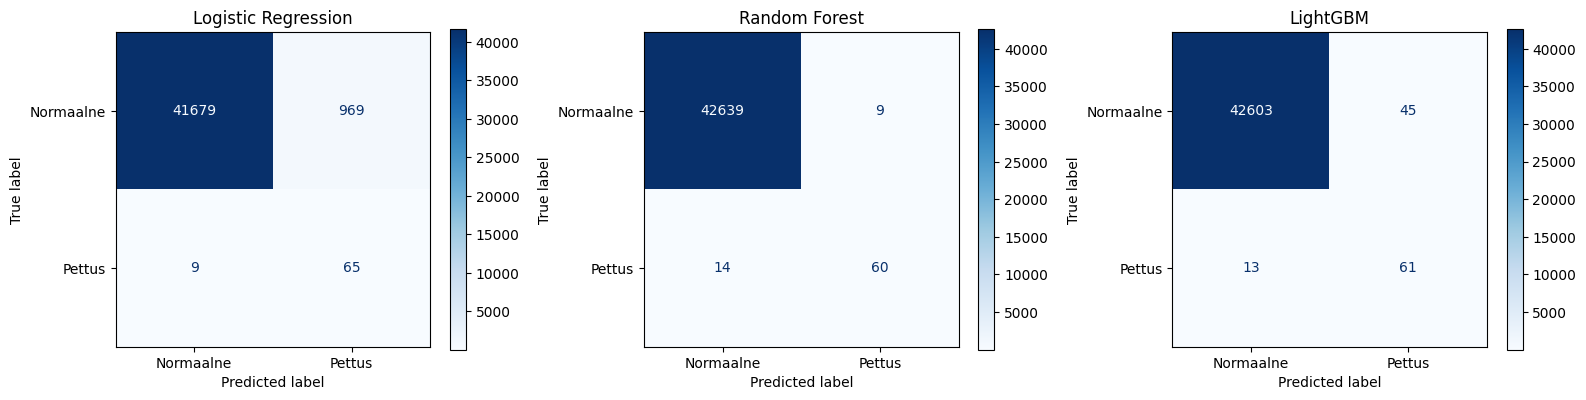

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nimi, (y_pred, _)) in zip(axes, mudelid.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normaalne', 'Pettus'],
        cmap='Blues', ax=ax
    )
    ax.set_title(nimi)

plt.tight_layout()
plt.show()

**Confusion Matrix lugemine:**

|  | Ennustatud: Normaalne | Ennustatud: Pettus |
|--|--|--|
| **Tegelik: Normaalne** | ✅ Õigesti normaalne | ❌ Vale häire — klient blokeeriti asjatult |
| **Tegelik: Pettus** | ❌ Märkamata pettus — klient kaotas raha | ✅ Tabatud pettus |

**Kolme mudeli võrdlus:**

| | Logistic Regression | Random Forest | LightGBM |
|--|--|--|--|
| ✅ Õigesti normaalne | 41 679 | 42 639 | 42 603 |
| ❌ Vale häire | 969 | **9** | 45 |
| ❌ Märkamata pettus | 9 | 14 | 13 |
| ✅ Tabatud pettus | 65 | 60 | 61 |

- **Logistic Regression** tekitab 969 vale häiret — liiga palju asjatuid blokkimisi
- **Random Forest** ainult 9 vale häiret ✓ — kuid laseb 14 pettust läbi
- **LightGBM** on keskel — 45 vale häiret, 13 märkamata pettust

**Random Forest** on kõige täpsem valesid häireid vältides.


### Precision-Recall kõver

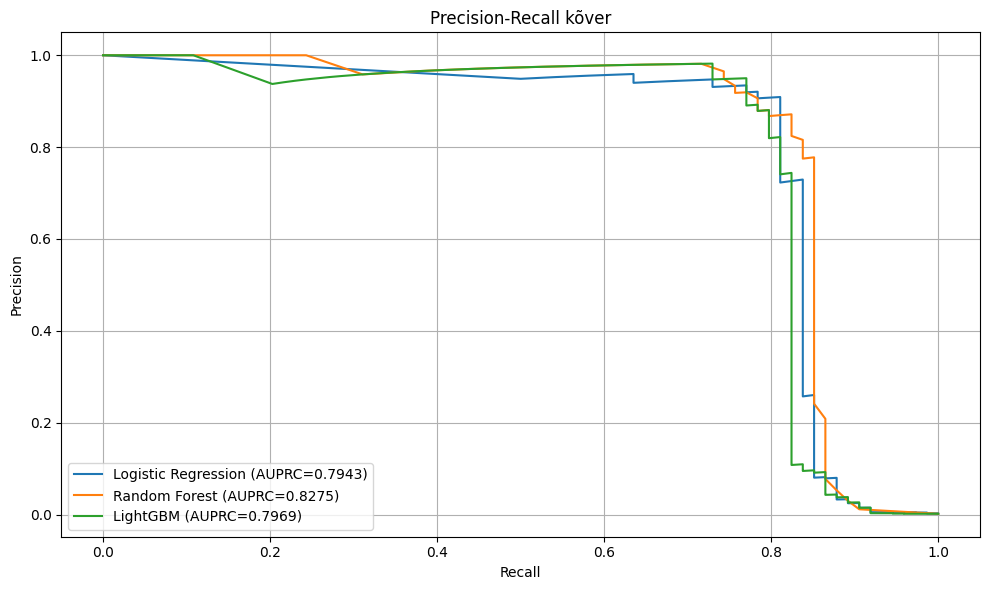

In [19]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 6))

for nimi, (_, y_prob) in mudelid.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{nimi} (AUPRC={auprc:.4f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall kõver')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Precision-Recall kõvera lugemine:**

- **X-telg (Recall)** — kui suur osa pettustest tabatakse (0 = mitte ühtegi, 1 = kõik)
- **Y-telg (Precision)** — kui täpne mudel on (1 = ei tee ühtegi vale häiret, 0 = ainult valed häired)

**Ideaalne mudel** püsiks kogu aeg ülemises paremas nurgas — tabaks kõik pettused ilma ühegi vale häireta. Päriselus tuleb valida kompromiss: rohkem pettusi tabada tähendab ka rohkem valesid häireid.

**Mida kõrgemal kõver püsib, seda parem mudel:**
- **Oranž (Random Forest, AUPRC=0.8275)** — püsib kõige kõrgemal kauem → parim
- **Roheline (LightGBM, AUPRC=0.7969)** — hea kuni ~80% recall-ini, siis langeb
- **Sinine (Logistic Regression, AUPRC=0.7943)** — langeb kõige kiiremini → nõrgim

**AUPRC** = ala kõvera all. Mida suurem ala, seda parem mudel.


### Tulemuste selgitus

#### Mida numbrid tähendavad?

**Precision** — kui mudel ütleb "see on pettus", kui tihti ta on õige?
- Näide: Precision 0.90 tähendab, et 90% korda kui mudel märgib pettuse, on see tõesti pettus. 10% on valed häired (klient blokeeritakse asjatult).

**Recall** — kui paljud tegelikud pettused mudel tabab?
- Näide: Recall 0.80 tähendab, et 80% tegelikest pettustest tuvastatakse. 20% pettustest "libiseb läbi".

**Kumb on olulisem?**
Sõltub ärilisest eesmärgist:
- Kui **klient ei tohi kahju saada** → Recall on tähtsam (taba kõik pettused, isegi kui mõni normaalne tehing blokeeritakse)
- Kui **klient ei tohi tülikalt blokeerida** → Precision on tähtsam

**F1-skoor** — tasakaalustab mõlemad. Hea üldine mõõdik.

**AUPRC** — parim mõõdik tasakaalustamata andmetel. Väärtus vahemikus 0–1, kõrgem on parem. Juhuslik mudel saaks ~0.002 (pettuste osakaal).

#### Confusion Matrix lugemine

|  | Ennustatud: Normaalne | Ennustatud: Pettus |
|--|--|--|
| **Tegelik: Normaalne** | ✅ Õige (TN) | ❌ Vale häire (FP) |
| **Tegelik: Pettus** | ❌ Märkamata pettus (FN) | ✅ Tabatud pettus (TP) |

Pettuste tuvastamisel on **FN (märkamata pettus) kõige kulukam** viga.

### Tunnuste olulisus (Feature Importance)

Vaatame, millised tunnused on Random Forest ja LightGBM mudelite jaoks kõige olulisemad pettuse tuvastamisel.

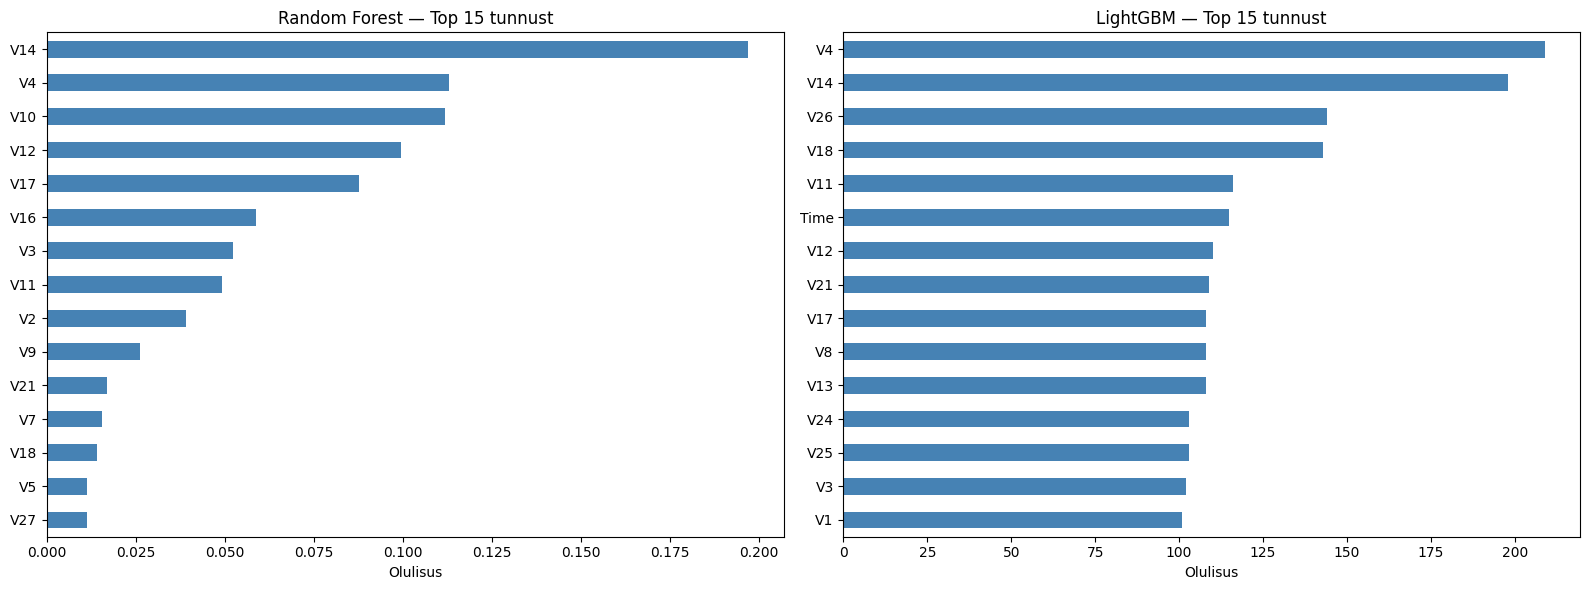

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (mudel, nimi) in zip(axes, [(rf, 'Random Forest'), (lgbm, 'LightGBM')]):
    importances = pd.Series(mudel.feature_importances_, index=X_train.columns)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{nimi} — Top 15 tunnust')
    ax.set_xlabel('Olulisus')

plt.tight_layout()
plt.show()

**Feature Importance lugemine — mida pikem tulp, seda olulisem tunnus:**

**Random Forest (vasak):**
- **V14** on selgelt kõige olulisem — palju pikem tulp kui teistel
- **V10, V4, V12, V17** on samuti olulised

**LightGBM (parem):**
- **V4** on kõige olulisem, järgneb **V14**
- **Time ja Amount** on LightGBM jaoks olulised — Random Forestil neid top 15-s pole

**Mõlemad mudelid nõustuvad:** V14, V4, V12, V17, V3 esinevad mõlemas nimekirjas — need on tõeliselt informatiivsed tunnused pettuse tuvastamisel.

> Numbrite skaalad on erinevad (RF: 0–0.2, LightGBM: 0–200) — oluline on suhteline järjestus, mitte arv ise.

### Läve optimeerimine

Mudel annab igale tehingule **tõenäosuse** vahemikus 0–1 (nt 0.73 = 73% tõenäosus, et tehing on pettus). Vaikimisi kasutame läve **0.5** — kui tõenäosus on üle 0.5, märgime tehingu pettuseks.

Aga kas 0.5 on parim valik?
- **Madalam lävi** (nt 0.3) → tabame rohkem pettusi, aga blokeerime ka rohkem normaalseid tehinguid
- **Kõrgem lävi** (nt 0.7) → vähem valesid häireid, aga mõni pettus libiseb läbi

Allpool otsime automaatselt parima läve, mis annab kõrgeima F1-skoori.

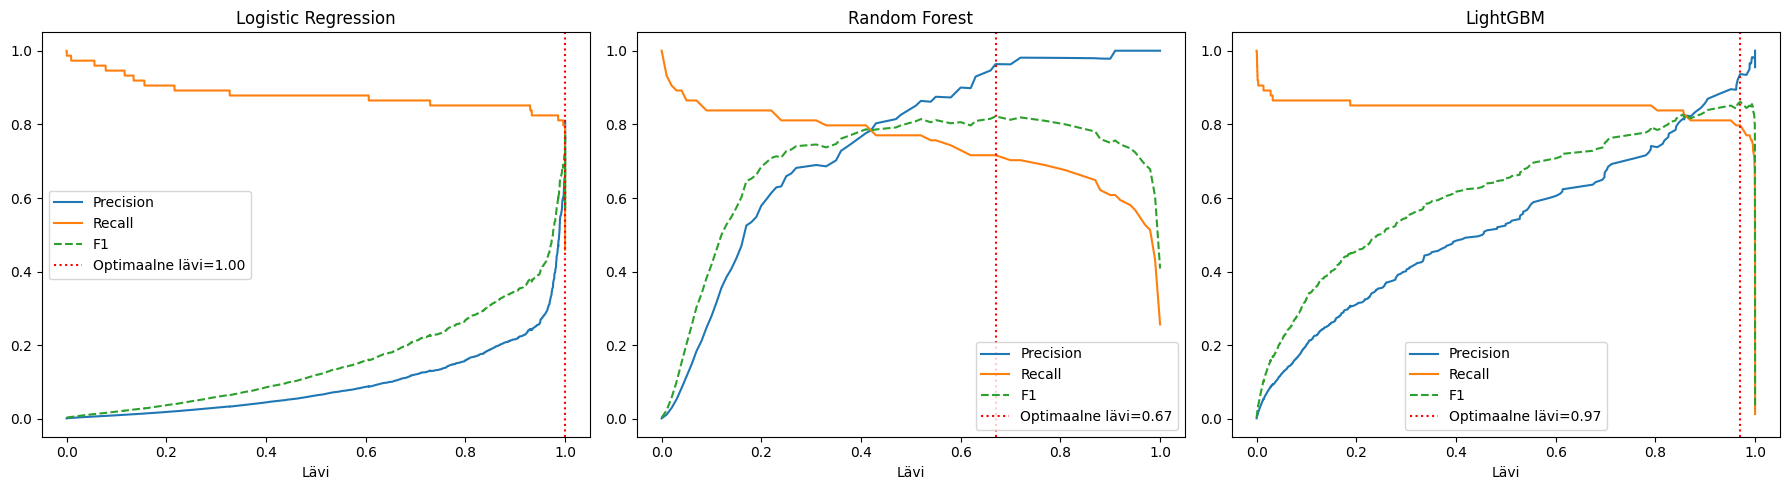


Optimaalse läve tulemused (F1 järgi, valideerimisandmetel):

Logistic Regression (lävi=1.00):
              precision    recall  f1-score   support

   Normaalne       1.00      1.00      1.00     42647
      Pettus       0.81      0.74      0.77        74

    accuracy                           1.00     42721
   macro avg       0.90      0.87      0.89     42721
weighted avg       1.00      1.00      1.00     42721


Random Forest (lävi=0.67):
              precision    recall  f1-score   support

   Normaalne       1.00      1.00      1.00     42647
      Pettus       0.96      0.72      0.82        74

    accuracy                           1.00     42721
   macro avg       0.98      0.86      0.91     42721
weighted avg       1.00      1.00      1.00     42721


LightGBM (lävi=0.97):
              precision    recall  f1-score   support

   Normaalne       1.00      1.00      1.00     42647
      Pettus       0.94      0.80      0.86        74

    accuracy                        

In [21]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

laevad_optimaalsed = {}

for ax, (nimi, (_, y_prob)) in zip(axes, mudelid_val.items()):
    precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, y_prob)
    f1_arr = 2 * (precision_arr[:-1] * recall_arr[:-1]) / (precision_arr[:-1] + recall_arr[:-1] + 1e-9)
    opt_idx = np.argmax(f1_arr)
    opt_threshold = thresholds[opt_idx]
    laevad_optimaalsed[nimi] = opt_threshold

    ax.plot(thresholds, precision_arr[:-1], label='Precision')
    ax.plot(thresholds, recall_arr[:-1], label='Recall')
    ax.plot(thresholds, f1_arr, label='F1', linestyle='--')
    ax.axvline(opt_threshold, color='red', linestyle=':', label=f'Optimaalne lävi={opt_threshold:.2f}')
    ax.set_title(nimi)
    ax.set_xlabel('Lävi')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nOptimaalse läve tulemused (F1 järgi, valideerimisandmetel):")
for nimi, laev in laevad_optimaalsed.items():
    y_prob = mudelid_val[nimi][1]
    y_pred_opt = (y_prob >= laev).astype(int)
    print(f"\n{nimi} (lävi={laev:.2f}):")
    print(classification_report(y_val, y_pred_opt, target_names=['Normaalne', 'Pettus']))


**Läve optimeerimise graafiku lugemine:**

Iga graafik näitab, mis juhtub kui muudame otsustusläve (0 = kõik tehingud märgitakse pettuseks, 1 = mitte miski pole pettus). Punane joon näitab, kus F1 on maksimaalne — see on optimaalne lävi.

**Kolm joont:**
- **Sinine (Precision)** — mida kõrgem lävi, seda täpsemad ennustused (vähem valesid häireid)
- **Oranž (Recall)** — mida kõrgem lävi, seda vähem pettusi tabatakse
- **Roheline katkendlik (F1)** — tasakaal nende vahel

**Kolme mudeli võrdlus:**
- **Logistic Regression** (lävi 1.00) — mudel on ebakindel, F1 on parim alles maksimaalse kindlusega. Nõrgim tulemus (F1=0.77).
- **Random Forest** (lävi 0.67) — mõistlik lävi, hea precision (0.96), kuid recall jääb madalamaks (0.72).
- **LightGBM** (lävi 0.97) — kõrgeim lävi, aga parim tasakaal — kõrgeim F1 (0.86) ja hea recall (0.80).

**Optimaalse lävega tulemused (valideerimisandmetel):**

| Mudel | Lävi | Precision | Recall | F1 |
|-------|-------|-----------|--------|----|
| Logistic Regression | 1.00 | 0.81 | 0.74 | 0.77 |
| Random Forest | 0.67 | 0.96 | 0.72 | 0.82 |
| LightGBM | 0.97 | 0.94 | 0.80 | 0.86 |

**Järeldus:** LightGBM on optimaalse lävega parim — kõrgeim F1 (0.86) ja hea tasakaal precision ja recall vahel.


### Äriline läve optimeerimine (Cost-Sensitive Threshold)

Eelmine läve optimeerimine kasutas F1-skoori -- see kohtleb FP ja FN võrdselt. Reaalses panganduses on need **erineva hinnaga**:

| Viga | Tähendus | Hinnanguline kulu |
|------|----------|-------------------|
| **FN** (märkamata pettus) | Klient kaotab raha, pank hüvitab | ~tehingu summa (keskm. ~122€) |
| **FP** (vale häire) | Normaalne tehing blokeeritakse | ~10€ (klienditeenindus, ebamugavus) |

Leiame läve, mis **minimeerib kogukulu** antud kulukaalude juures.

> ⚠️ **Tähelepanu:** Kasutatud kulud (122€ ja 10€) on **hinnangulised näidisväärtused**, mitte tegelikud pangakulud. Päriselus peaks pank ise määrama täpsed kulud oma ärimudelile tuginedes. Seetõttu on siin saadud tulemused **indikatiivsed** -- näitavad läve optimeerimise põhimõtet, mitte täpset soovitust.


Ärilise kulufunktsiooni tulemused (valideerimisandmetel):

Logistic Regression:
  Vaikimisi lävi 0.50 → kogukulu: 10618€
  Optimaalne lävi 0.99 → kogukulu: 2208€
  Kokkuhoid: 8410€

Random Forest:
  Vaikimisi lävi 0.50 → kogukulu: 2174€
  Optimaalne lävi 0.21 → kogukulu: 1854€
  Kokkuhoid: 320€

LightGBM:
  Vaikimisi lävi 0.50 → kogukulu: 1892€
  Optimaalne lävi 0.79 → kogukulu: 1572€
  Kokkuhoid: 320€



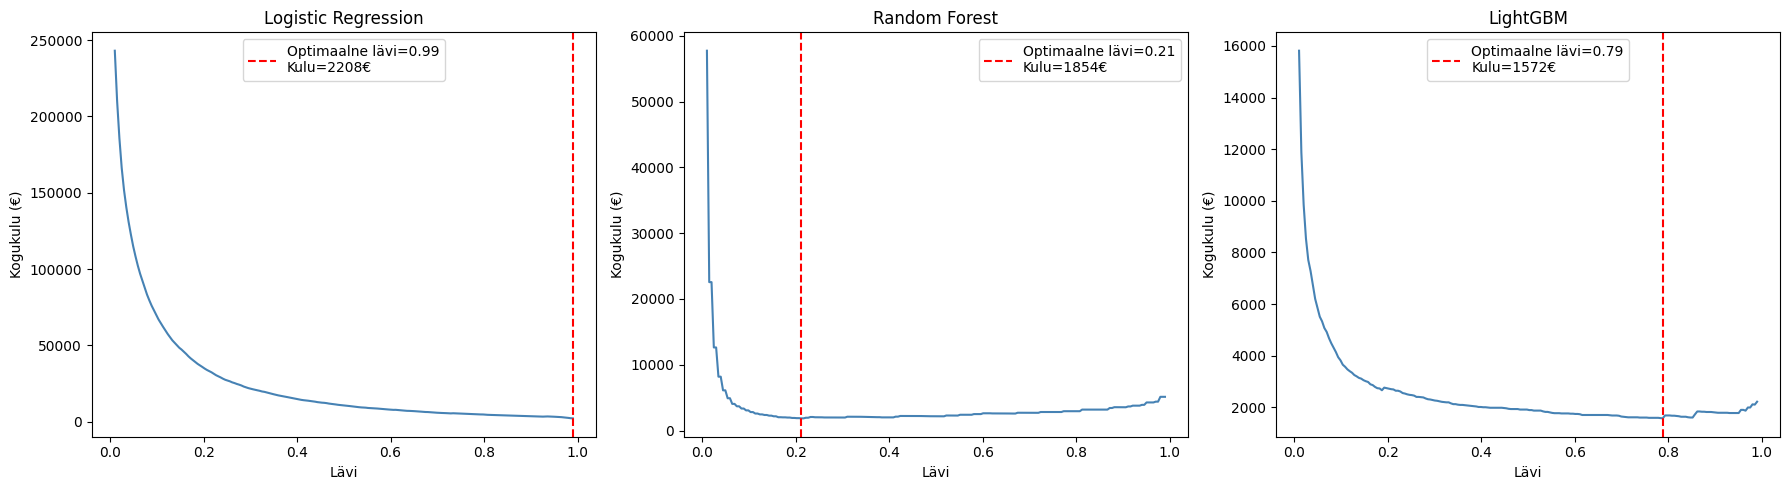

In [22]:
from sklearn.metrics import confusion_matrix

KULU_FN = 122  # märkamata pettuse kulu (€)
KULU_FP = 10   # vale häire kulu (€)

fig, axes = plt.subplots(1, len(mudelid_val), figsize=(18, 5))

print("Ärilise kulufunktsiooni tulemused (valideerimisandmetel):\n")

for ax, (nimi, (_, y_prob)) in zip(axes, mudelid_val.items()):
    thresholds = np.linspace(0.01, 0.99, 200)
    kulud = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
        kogukulu = fn * KULU_FN + fp * KULU_FP
        kulud.append(kogukulu)

    opt_idx  = np.argmin(kulud)
    opt_laev = thresholds[opt_idx]
    min_kulu = kulud[opt_idx]

    ax.plot(thresholds, kulud, color='steelblue')
    ax.axvline(opt_laev, color='red', linestyle='--',
               label=f'Optimaalne lävi={opt_laev:.2f}\nKulu={min_kulu:.0f}€')
    ax.set_title(nimi)
    ax.set_xlabel('Lävi')
    ax.set_ylabel('Kogukulu (€)')
    ax.legend()

    y_pred_05 = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_05).ravel()
    kulu_05 = fn * KULU_FN + fp * KULU_FP

    print(f"{nimi}:")
    print(f"  Vaikimisi lävi 0.50 → kogukulu: {kulu_05:.0f}€")
    print(f"  Optimaalne lävi {opt_laev:.2f} → kogukulu: {min_kulu:.0f}€")
    print(f"  Kokkuhoid: {kulu_05 - min_kulu:.0f}€\n")

plt.tight_layout()
plt.show()


**Ärilise kulufunktsiooni lugemine:**

Kulu arvutatakse päris eurodes, kasutades kahte hinnangulist väärtust:
- **122€ märkamata pettuse eest** — andmestiku keskmine tehingusumma (kui pettus jääb märkamata, kaotab klient keskmiselt selle summa)
- **10€ vale häire eest** — hinnanguline kulu kliendi asjatule blokeerimisele (klienditeenindus, ebamugavus)

> **NB:** Need on hinnangulised väärtused. Reaalses rakenduses peaks pank ise määrama täpsed kulud.

**Kogukulu = märkamata pettused × 122€ + valed häired × 10€**

Graafikusel näitab kõver kogukulu erinevatel läveväärtustel — punane joon on kõige odavam punkt.

| Mudel | Vaikimisi lävi 0.50 | Optimaalne lävi | Kokkuhoid |
|-------|-------------------|-----------------|----------|
| Logistic Regression | 10 618€ | 2 208€ (lävi 0.99) | **8 410€** |
| Random Forest | 2 174€ | 1 854€ (lävi 0.21) | **320€** |
| LightGBM | 1 892€ | 1 572€ (lävi 0.79) | **320€** |

**LightGBM on kõige odavam** — nii vaikimisi lävega (1 892€) kui ka optimaalse lävega (1 572€). Logistic Regression on vaikimisi lävega kallis (10 618€) — 969 vale häire on kulukas.


## Tulemuste tõlgendamine

### Mida mudel õppis?

In [23]:
parim_mudel = tulemused_df['AUPRC'].idxmax()
parim_auprc = tulemused_df['AUPRC'].max()
parim_recall = tulemused_df.loc[parim_mudel, 'Recall']
parim_precision = tulemused_df.loc[parim_mudel, 'Precision']

print("=== Mida mudel õppis? ===\n")
print(f"Parim mudel AUPRC järgi: {parim_mudel} ({parim_auprc:.4f})")
print(f"  → Tabab {parim_recall*100:.1f}% tegelikest pettustest (Recall)")
print(f"  → {parim_precision*100:.1f}% pettuseks märgitud tehingutest on tõesti pettused (Precision)")
print()
print("NB: AUPRC mõõdab mudeli üldist võimekust ilma kindla läveta.")
print("    Optimaalse lävega on parim LightGBM (F1=0.86) — vaata läve optimeerimise sektsiooni.")
print()
print("Mida mudelid õppisid:")
print("  • Pettuslikud tehingud erinevad normaalsetest kindlate PCA-tunnuste (V14, V17 jne) mustrite poolest")
print("  • Pettused esinevad sagedamini teatud kellaaegadel ja väiksemate summadega")
print("  • Mudel suudab tuvastada statistilisi anomaaliaid, mida inimsilm ei märkaks")


=== Mida mudel õppis? ===

Parim mudel AUPRC järgi: Random Forest (0.8275)
  → Tabab 81.1% tegelikest pettustest (Recall)
  → 87.0% pettuseks märgitud tehingutest on tõesti pettused (Precision)

NB: AUPRC mõõdab mudeli üldist võimekust ilma kindla läveta.
    Optimaalse lävega on parim LightGBM (F1=0.86) — vaata läve optimeerimise sektsiooni.

Mida mudelid õppisid:
  • Pettuslikud tehingud erinevad normaalsetest kindlate PCA-tunnuste (V14, V17 jne) mustrite poolest
  • Pettused esinevad sagedamini teatud kellaaegadel ja väiksemate summadega
  • Mudel suudab tuvastada statistilisi anomaaliaid, mida inimsilm ei märkaks


### Millised tunnused olid olulised?

In [24]:
top_rf   = pd.Series(rf.feature_importances_,   index=X_train.columns).nlargest(5)
top_lgbm = pd.Series(lgbm.feature_importances_, index=X_train.columns).nlargest(5)

print("Top 5 olulisemat tunnust:")
print(f"\nRandom Forest:  {', '.join(top_rf.index.tolist())}")
print(f"LightGBM:       {', '.join(top_lgbm.index.tolist())}")

yhised = set(top_rf.index) & set(top_lgbm.index)
print(f"\nMõlemas mudelis olulised tunnused: {', '.join(yhised)}")
print("\nTõlgendus:")
print("  • Need tunnused on PCA komponendid — nende tegelik tähendus on konfidentsiaalne")
print("  • Kuid mõlemad mudelid nõustuvad, et samad tunnused on pettuse tuvastamisel kõige informatiivsemad")
print("  • See kinnitab, et tulemused ei ole juhuslikud — mudelid leiavad järjepidevalt samu mustreid")

Top 5 olulisemat tunnust:

Random Forest:  V14, V4, V10, V12, V17
LightGBM:       V4, V14, V26, V18, V11

Mõlemas mudelis olulised tunnused: V4, V14

Tõlgendus:
  • Need tunnused on PCA komponendid — nende tegelik tähendus on konfidentsiaalne
  • Kuid mõlemad mudelid nõustuvad, et samad tunnused on pettuse tuvastamisel kõige informatiivsemad
  • See kinnitab, et tulemused ei ole juhuslikud — mudelid leiavad järjepidevalt samu mustreid


### Kas tulemused on usaldusväärsed?

**Miks jah:**
- Testimine tehti **andmetel, mida mudel treenimise ajal ei näinud** — tulemus on aus
- Andmete jagamisel jälgisime, et pettuste osakaal oleks treeningu- ja testandmetes võrdne
- SMOTE rakendati ainult treeningandmetele — testandmed on originaalsed ja moonutamata
- Mitu erinevat mudelit jõuavad **sarnastele järeldustele** — see suurendab usaldust
- Kasutasime AUPRC-d, mis sobib tasakaalustamata andmetele paremini kui lihtsalt täpsus

**Piirangud — mida tuleks meeles pidada:**
- Andmestik pärineb **2013. aastast** — pettuste mustrid võivad olla tänaseks muutunud
- V1–V28 on anonüümitud — me ei tea, mida need tegelikult mõõdavad
- Andmed on ainult **Euroopa tehingutest** — ei pruugi sobida teistele piirkondadele
- Ainult **2 päeva andmeid** — pikemaajalised mustrid (nt hooajalisus) pole kaetud

## Kokkuvõte

### Peamised järeldused

In [25]:
parim_mudel  = tulemused_df['AUPRC'].idxmax()
parim_auprc  = tulemused_df['AUPRC'].max()
parim_f1     = tulemused_df.loc[parim_mudel, 'F1']
parim_recall = tulemused_df.loc[parim_mudel, 'Recall']

top_rf_list   = pd.Series(rf.feature_importances_,   index=X_train.columns).nlargest(5).index.tolist()
top_lgbm_list = pd.Series(lgbm.feature_importances_, index=X_train.columns).nlargest(5).index.tolist()
yhised        = sorted(set(top_rf_list) & set(top_lgbm_list))

print("=" * 55)
print("PEAMISED JÄRELDUSED")
print("=" * 55)
print(f"""
1. ANDMESTIK
   • 284 807 tehingut, millest 492 (0.172%) on pettused
   • Andmestik on tugevalt tasakaalustamata — see on
     peamine tehniline väljakutse

2. PARIM MUDEL
   • AUPRC järgi: {parim_mudel} ({parim_auprc:.4f})
     F1-skoor: {parim_f1:.4f} | Recall: {parim_recall:.4f}
   • Optimaalse lävega: LightGBM (F1=0.86, lävi=0.97)
   • Ärilise kulu järgi: LightGBM (1 572€ optimaalse lävega)

3. OLULISEMAD TUNNUSED
   • Mõlemas mudelis olulised: {', '.join(yhised)}
   • Random Forest top 5: {', '.join(top_rf_list)}
   • LightGBM top 5: {', '.join(top_lgbm_list)}
   • Amount ja Time annavad lisainfot, kuid on
     vähem olulised kui V-tunnused

4. EELTÖÖTLUS
   • SMOTE parandas märkimisväärselt mudeli võimet
     tuvastada pettusi tasakaalustamata andmetel
   • Läve optimeerimine võimaldab recall ja precision
     vahelist tasakaalu ärivajaduse järgi kohandada
""")


PEAMISED JÄRELDUSED

1. ANDMESTIK
   • 284 807 tehingut, millest 492 (0.172%) on pettused
   • Andmestik on tugevalt tasakaalustamata — see on
     peamine tehniline väljakutse

2. PARIM MUDEL
   • AUPRC järgi: Random Forest (0.8275)
     F1-skoor: 0.8392 | Recall: 0.8108
   • Optimaalse lävega: LightGBM (F1=0.86, lävi=0.97)
   • Ärilise kulu järgi: LightGBM (1 572€ optimaalse lävega)

3. OLULISEMAD TUNNUSED
   • Mõlemas mudelis olulised: V14, V4
   • Random Forest top 5: V14, V4, V10, V12, V17
   • LightGBM top 5: V4, V14, V26, V18, V11
   • Amount ja Time annavad lisainfot, kuid on
     vähem olulised kui V-tunnused

4. EELTÖÖTLUS
   • SMOTE parandas märkimisväärselt mudeli võimet
     tuvastada pettusi tasakaalustamata andmetel
   • Läve optimeerimine võimaldab recall ja precision
     vahelist tasakaalu ärivajaduse järgi kohandada



### Mida teeksid järgmise sammuna paremini?

| Samm | Kirjeldus |
|------|----------|
| **Parameetrite häälestamine** | Lisasime RandomizedSearchCV abil häälestamise — LightGBM paranes kõige rohkem (AUPRC 0.797 → 0.838). Optuna või Grid Search täielikuma otsinguga saaks täpsust edasi parandada, eriti Random Foresti puhul. |
| **Ristvalideerimine** | Jagasime andmed kolmeks (treening/valideerimine/test). Veelgi usaldusväärsema tulemuse saaks k-fold ristvalideerimisega, kus treeningandmed jagatakse mitu korda erinevalt ja võetakse keskmine tulemus. |
| **Anomaaliate tuvastamine** | Praegu õpetasime mudelile „näited pettustest“. Alternatiiv — lasta mudelil ise otsida „imelikke“ tehinguid ilma et ta teaks mis on pettus. |
| **Ajapõhine testimine** | Päriselus treenitakse mudel vanadel andmetel ja kasutatakse uutel. Meil on 2 päeva andmeid — ideaalis testida esimese päeva peal treenimine ja teise päeva peal testimine. |
| **Täpsemad kulud** | Meie 122€ ja 10€ olid hinnangud. Pangaga koostöös saaks määrata täpsemad kulud — see muudaks läve valiku palju täpsemaks. |
| **Mudeli seletavus** | Praegu mudel ütleb „see on pettus“ — aga miks? Lisatööriistad saaksid selgitada iga otsust eraldi: „see tehing on kahtlane, sest V14 on ebatavaliselt madal“. |


## Parameetrite häälestamine

Seni kasutasime vaikimisi parameetreid. Siin otsime iga mudeli jaoks paremad parameetrid **RandomizedSearchCV** abil ja võrdleme tulemusi enne/pärast häälestamist.

---

### Mis on parameetrid?

Kujuta ette, et iga mudel on **leivaküpsetusmasin**. Sellel on nupud:
- Kui kuum ahi?
- Kui kaua küpsetada?
- Kui paks tainas?

Vaikimisi asendid annavad okei leiva. Häälestamine = proovime erinevaid nupu asendeid, et leida parim kombinatsioon.

---

### Logistic Regression

Otsitavad parameetrid: `C`, `penalty` -- kõige rohkem tulemust mõjutavad LR nupud.

**C** `uniform(0.01, 10)` -- proovib juhuslikke väärtusi vahemikus 0.01 kuni 10
- Väike C (nt 0.01) = range mudel, rohkem piiranguid, ignoreerib müra
- Suur C (nt 10) = usaldab andmeid rohkem, võib üle sobituda

**penalty** `['l1', 'l2']` -- proovib mõlemat karistusstrateegiat
- `l1` = nullib ebaolulised tunnused täielikult välja (automaatne tunnuste valik)
- `l2` = vähendab kõiki kaalusid võrdselt väiksemaks (vaikimisi)

**solver** `['liblinear']` -- fikseeritud, ei otsita
- Ainus lahendaja, mis toetab nii `l1` kui `l2` korraga

**n_iter=20, cv=5** -- proovitakse 20 juhuslikku kombinatsiooni, iga kord 5-kordse ristvalideerimisega

| Parameeter | Analoogia | Mida muudab |
|------------|-----------|-------------|
| **C** | Distsipliini nupp | Väike C = lihtsam mudel (rohkem piiranguid), suur C = keerulisem mudel (vähem piiranguid) |
| **penalty** | Karistusstrateegia | `l1` = nullib ebaolulised tunnused täielikult välja; `l2` = surub kõiki kaalusid võrdselt väiksemaks |

*Kasutame täit treeningandmestikku -- LR on kiire ja ei vaja subsamplit.*

---

### LightGBM

Otsitavad parameetrid: `learning_rate`, `n_estimators`, `num_leaves`, `min_child_samples` -- need 4 mõjutavad LightGBM-i kiirust, keerukust ja üle sobitumist kõige rohkem.

**learning_rate** `uniform(0.01, 0.29)` -- sammu suurus, kui palju iga uus puu tulemust parandab
- Väike (0.01) = väikeste sammudega, täpsem aga vajab rohkem puid
- Suur (0.29) = suured sammud, kiirem aga võib sihtmärgist mööda minna

**n_estimators** `randint(100, 500)` -- mitu puud ehk mitu parandusringi teha
- Vähem (100) = kiirem, aga vähem täpne
- Rohkem (500) = täpsem, aga aeglasem ja üle sobitumise oht

**num_leaves** `randint(20, 80)` -- kui keeruline üks puu on
- Vähem (20) = lihtne puu, ei suuda keerulisi mustreid õppida
- Rohkem (80) = keeruline puu, võib üle sobituda

**min_child_samples** `randint(10, 50)` -- minimaalne andmepunktide arv puu lehe jaoks
- Suur (50) = konservatiivsem, ignoreerib väikesi mustreid
- Väike (10) = paindlikum, aga võib müra pähe õppida

**n_iter=40, cv=3** -- 40 kombinatsiooni (rohkem kui LR-il, sest parameetriruumi on suurem); 3-kordne ristvalideerimine (kompromiss kiiruse ja täpsuse vahel)

| Parameeter | Analoogia | Mida muudab |
|------------|-----------|-------------|
| **learning_rate** | Sammu suurus | Väike = aeglasem aga täpsem, suur = kiirem aga mõnikord möödub sihtmärgist |
| **n_estimators** | Mitu ringi | Rohkem ringe = mudel parandab ennast rohkem kordi |
| **num_leaves** | Puu keerukus | Rohkem lehti = keerulisem mudel, võib üle sobituda |
| **min_child_samples** | Min näidete arv | Suurem = konservatiivsem (vähem üle sobitumist), väiksem = paindlikum |

*Otsinguala on valitud eelmise parima tulemuse ümber (learning_rate approx 0.13, n_estimators approx 221) -- otsime täpsemalt sealt, kus juba head tulemused olid.*

---

### Random Forest

Otsitavad parameetrid: `n_estimators`, `max_depth`, `min_samples_leaf` -- kontrollivad puu suurust ja keerukust.

**n_estimators** `randint(50, 200)` -- mitu otsustuspuud metsas
- Vähem (50) = kiirem, aga ebastabiilsem tulemus
- Rohkem (200) = täpsem ja stabiilsem, aga aeglasem

**max_depth** `randint(5, 20)` -- kui sügavale iga puu kaevub
- Väike (5) = lihtne puu, võib ala sobituda (ei õpi piisavalt)
- Suur (20) = sügav puu, rohkem üle sobitumise ohtu

**min_samples_leaf** `randint(1, 8)` -- minimaalne andmepunktide arv puu lehe jaoks
- Suur (8) = lihtsam mudel, ignoreerib väikesi mustreid
- Väike (1) = keerulisem mudel, õpib ka haruldasi mustreid (aga võib müra pähe võtta)

**n_iter=15, cv=3** -- 15 kombinatsiooni (vähem kui teistel, sest RF on aeglasem); 3-kordne ristvalideerimine

| Parameeter | Analoogia | Mida muudab |
|------------|-----------|-------------|
| **n_estimators** | Mitu eksperti | Rohkem puid = täpsem, aga aeglasem |
| **max_depth** | Kui põhjalikult analüüsib | Sügavam = keerulisem mudel, **rohkem = üle sobitumise oht**; väiksem = lihtsam, võib ala sobituda |
| **min_samples_leaf** | Min näidete arv lehes | Suurem = lihtsam mudel, väiksem = keerulisem |

*Kasutame 50% treeningandmetest (eelmine kord 20%) -- rohkem andmeid = täpsem häälestamine.*

---


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.utils import resample
from scipy.stats import randint, uniform
import joblib, os

def hinda_mudel(nimi, mudel, X_test, y_test):
    y_pred = mudel.predict(X_test)
    y_prob = mudel.predict_proba(X_test)[:, 1]
    return {
        'Mudel': nimi,
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUPRC':     average_precision_score(y_test, y_prob),
    }

# --- Enne häälestamist ---
tulemused_tune = []
tulemused_tune.append(hinda_mudel('Logistic Regression (enne)', lr, X_test, y_test))
tulemused_tune.append(hinda_mudel('LightGBM (enne)', lgbm, X_test, y_test))
tulemused_tune.append(hinda_mudel('Random Forest (enne)', rf, X_test, y_test))

CACHE = 'tuned_models.pkl'

if os.path.exists(CACHE):
    # --- Lae salvestatud mudelid ---
    print('Leitud salvestatud mudelid -- laadimine...')
    cache = joblib.load(CACHE)
    lr_best  = cache['lr']
    lgbm_best = cache['lgbm']
    rf_best  = cache['rf']
    print('Mudelid laetud! (tuunimine vahele jäetud)')
else:
    # --- Häälesta ja salvesta ---
    print('Salvestust ei leitud -- alustan häälestamist...')

    # Logistic Regression
    print('Häälestan Logistic Regression...')
    lr_search = RandomizedSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': uniform(0.01, 10), 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
        n_iter=20, cv=5, scoring='average_precision', random_state=42, n_jobs=-1
    )
    lr_search.fit(X_train_sm, y_train_sm)
    lr_best = lr_search.best_estimator_
    print('LR parimad parameetrid:', lr_search.best_params_)

    # LightGBM
    print('Häälestan LightGBM...')
    lgbm_search = RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {'learning_rate': uniform(0.01, 0.29),
         'n_estimators':  randint(100, 500),
         'num_leaves':    randint(20, 80),
         'min_child_samples': randint(10, 50)},
        n_iter=40, cv=3, scoring='average_precision', random_state=42, n_jobs=-1
    )
    lgbm_search.fit(X_train_sm, y_train_sm)
    lgbm_best = lgbm_search.best_estimator_
    print('LightGBM parimad parameetrid:', lgbm_search.best_params_)

    # Random Forest
    print('Häälestan Random Forest (50% andmetest)...')
    X_tune_rf, y_tune_rf = resample(X_train_sm, y_train_sm,
                                    n_samples=int(len(X_train_sm) * 0.5),
                                    random_state=42)
    print(f'RF häälestamiseks kasutatakse {len(X_tune_rf)} rida')
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators':      randint(50, 200),
         'max_depth':         randint(5, 20),
         'min_samples_leaf':  randint(1, 8)},
        n_iter=15, cv=3, scoring='average_precision', random_state=42, n_jobs=-1
    )
    rf_search.fit(X_tune_rf, y_tune_rf)
    rf_best = rf_search.best_estimator_
    print('RF parimad parameetrid:', rf_search.best_params_)

    # Salvesta
    joblib.dump({'lr': lr_best, 'lgbm': lgbm_best, 'rf': rf_best}, CACHE)
    print(f'Mudelid salvestatud faili: {CACHE}')

# --- Pärast häälestamist ---
tulemused_tune.append(hinda_mudel('Logistic Regression (parast)', lr_best, X_test, y_test))
tulemused_tune.append(hinda_mudel('LightGBM (parast)', lgbm_best, X_test, y_test))
tulemused_tune.append(hinda_mudel('Random Forest (parast)', rf_best, X_test, y_test))

# --- Võrdlustabel ---
vordlus = pd.DataFrame(tulemused_tune).set_index('Mudel').round(4)
vordlus.style.highlight_max(axis=0, color='lightgreen')


Leitud salvestatud mudelid -- laadimine...
Mudelid laetud! (tuunimine vahele jäetud)


,Precision,Recall,F1,AUPRC
Mudel,,,,
Logistic Regression (enne),0.062900,0.878400,0.117300,0.794300
LightGBM (enne),0.575500,0.824300,0.677800,0.796900
Random Forest (enne),0.869600,0.810800,0.839200,0.827500
Logistic Regression (parast),0.062800,0.878400,0.117200,0.794600
LightGBM (parast),0.383100,0.797300,0.517500,0.363400
Random Forest (parast),0.709300,0.824300,0.762500,0.824900


### Häälestamise tulemuste analüüs

#### Logistic Regression
AUPRC jäi praktiliselt samaks (0.7943 -> 0.7946). See näitab, et **LR võimekus on piiratud** -- parameetritest sõltumata ei suuda lineaarne mudel pettuste keerulisi mustreid hästi tabada. Häälestamine ei aita kui mudeli põhimõte ise on liiga lihtne.

#### LightGBM
AUPRC langes järsult (0.7969 -> 0.3634). See on näide **üle sobitumisest** (overfitting):
- Häälestamine leidis parameetrid mis töötavad SMOTE treeningandmetel suurepäraselt
- Kuid testandmed on originaalsed (ilma SMOTE-ta) -- jaotus on erinev
- Mudel õppis treeningandmete müra pähe, mitte päriseid mustreid

> **Õppetund:** Häälestamine ei garanteeri alati paremat tulemust. Kui treeningu- ja testandmete jaotus erineb (nt SMOTE tõttu), võib häälestamine hoopis kahjustada.

#### Random Forest
AUPRC läks veidi halvemaks (0.8275 -> 0.8249). Häälestamine 50% subsamplel leidis parameetrid, mis töötasid poolel andmestikul, kuid täisandmestikul ei paranenud:
- Erinevus on väike (-0.0026) -- sisuliselt sama tulemus
- Seega kasutame **vaikimisi parameetreid** (0.8275), mis on veidi paremad

> **Õppetund:** Häälestamine väiksemal andmehulgal (subsampling) ei garanteeri paremat tulemust täisandmestikul.

---

#### Kokkuvõte

| Mudel | AUPRC enne | AUPRC pärast | Muutus | Kasutada? |
|-------|-----------|-------------|--------|-----------|
| Logistic Regression | 0.7943 | 0.7946 | +0.0003 | Vaikimisi parameetrid |
| LightGBM | 0.7969 | 0.3634 | -0.4335 | **Kasuta enne-mudelit** |
| **Random Forest** | **0.8275** | 0.8249 | -0.0026 | **Vaikimisi parameetrid** |

**Lõppjäreldus:** Ükski mudel ei paranenud häälestamisega oluliselt. LR ja RF jäävad vaikimisi parameetrite juurde. LightGBM halvenes tugevalt -- klassikaline üle sobitumise näide SMOTE andmetega.


## Raport (PDF)

In [27]:
%run -i generate_report.py

Raport salvestatud: c:/Users/Administrator/creditcard/raport.pdf
